Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.fft import fft
import pywt

## Load Processed Dataset

This cell loads the processed battery feature dataset from the `data_processed` directory.  
The file `features_cycle_with_core_fixed.parquet` is read using Pandas, and the column names are printed to inspect the available features and targets.

In [2]:
DATA_PROCESSED = Path("data_processed")

df = pd.read_parquet(DATA_PROCESSED/"features_cycle_with_core_fixed.parquet")

print(df.columns.tolist())

['n_samples', 'duration_s', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_p25', 'v_p50', 'v_p75', 'i_mean', 'i_std', 'i_abs_mean', 'i_max', 'temp_mean', 'temp_max', 'dvdt_max', 'dvdt_min', 'dvdt_abs_mean', 'power_mean', 'energy_sum', 'rc_OCV', 'rc_R0', 'rc_R1', 'rc_C1', 'rc_R2', 'rc_C2', 'rc_rmse', 'cell_id', 'cycle', 'dataset', 'chemistry', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'current_mean', 'current_std', 'current_min', 'current_max', 'temp_std', 'cycle_duration', 'charge_throughput', 'rc_estimate', 'energy_roll5', 'energy_norm', 'power_temp_xcorr_lag', 'core_peak_sim', 'core_mean_sim']


In [5]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [6]:
df.head()

,n_samples,duration_s,v_mean,v_std,v_min,v_max,v_p25,v_p50,v_p75,i_mean,i_std,i_abs_mean,i_max,temp_mean,temp_max,dvdt_max,dvdt_min,dvdt_abs_mean,power_mean,energy_sum,rc_OCV,rc_R0,rc_R1,rc_C1,rc_R2,rc_C2,rc_rmse,cell_id,cycle,dataset,chemistry,voltage_mean,voltage_std,voltage_min,voltage_max,current_mean,current_std,current_min,current_max,temp_std,cycle_duration,charge_throughput,rc_estimate,energy_roll5,energy_norm,power_temp_xcorr_lag,core_peak_sim,core_mean_sim
0,1254.0,1253.0,4.203433,0.252992,2.1989,4.3498,4.293100,4.2934,4.293400,3.849620,11.719256,3.849620,48.25985,-0.168316,58.03571,NaN,NaN,NaN,16.429577,20602.689211,4.244568,0.000105,0.002455,209.674498,0.001009,511.804615,0.261557,CALB_0_B182,0,CALB,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20602.689211,2.949082,NaN,120.000000,31.840761
1,288.0,287.0,3.913968,0.403421,2.1995,4.3498,3.551300,3.9293,4.334325,16.309492,19.221720,16.309492,47.58802,-0.208274,58.03571,NaN,NaN,NaN,69.600878,20045.052928,3.956914,0.000169,0.002473,203.486009,0.000990,511.275385,0.459559,CALB_0_B182,1,CALB,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20323.871069,2.857144,NaN,110.353767,32.797327
2,294.0,293.0,3.928304,0.401114,2.1995,4.3498,3.571150,3.9446,4.349500,17.059141,19.514978,17.059141,47.66443,0.020772,58.03571,NaN,NaN,NaN,72.925674,21440.148067,3.970910,0.000151,0.002553,192.472968,0.000968,509.741388,0.459247,CALB_0_B182,2,CALB,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20695.963402,3.087156,NaN,115.112422,35.256053
3,298.0,297.0,3.929014,0.409838,2.1995,4.3501,3.575225,3.9488,4.349800,17.276408,19.600400,17.276408,47.65250,-0.178960,58.04191,NaN,NaN,NaN,73.910002,22025.180603,3.976409,0.000176,0.002381,206.138683,0.001004,510.341489,0.486316,CALB_0_B182,3,CALB,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21028.267702,3.183612,NaN,116.696355,36.037185
4,299.0,298.0,3.930865,0.410678,2.1999,4.3501,3.579150,3.9512,4.350100,17.347262,19.601736,17.347262,47.56681,-0.212930,58.04191,NaN,NaN,NaN,74.237419,22196.988142,3.977282,0.000175,0.002610,188.343933,0.000967,509.109230,0.470249,CALB_0_B182,4,CALB,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21262.011790,3.211938,NaN,117.080175,36.319280


## Compute Voltage Change Features

This step creates new features based on the **change in voltage over time within each cycle**.

- `dV`: Change in voltage between consecutive measurements within each `cell_id` and `cycle`.
- `dt`: Time step difference between consecutive data points.
- `dV_dt`: Rate of voltage change calculated as `dV / dt`.

These features help capture **dynamic voltage behavior during battery operation**, which can be useful for model training.

In [3]:
df["dV"] = df.groupby(["cell_id","cycle"])["voltage"].diff()
df["dt"] = df.groupby(["cell_id","cycle"]).cumcount().diff().fillna(1)

df["dV_dt"] = df["dV"] / df["dt"]

In [4]:
dvdt_features = df.groupby(["cell_id","cycle"]).agg({
    "dV_dt": ["mean","std","min","max"]
})

dvdt_features.columns = ["_".join(col) for col in dvdt_features.columns]
dvdt_features = dvdt_features.reset_index()

dvdt_features.head()

,cell_id,cycle,dV_dt_mean,dV_dt_std,dV_dt_min,dV_dt_max
0,B0005,0,0.000163,0.008913,-0.332256,0.445253
1,B0006,0,0.000135,0.009798,-0.364780,0.490291
2,B0007,0,0.000194,0.006491,-0.215973,0.340512
3,B0018,0,0.000224,0.010339,-0.374064,0.510940
4,B0025,0,0.000131,0.016115,-0.996064,0.569048


## Aggregate dV/dt Features

This step summarizes the **voltage change rate (`dV_dt`) for each battery cycle**.

The data is grouped by **`cell_id` and `cycle`**, and the following statistics are computed:
- Mean
- Standard deviation
- Minimum
- Maximum

The resulting columns are flattened for easier use in modeling, and the aggregated feature table is displayed.

In [5]:
df["voltage_drop_event"] = (df["dV_dt"] < -0.01).astype(int)

motif_counts = df.groupby(["cell_id","cycle"])["voltage_drop_event"].sum().reset_index()

motif_counts.head()

,cell_id,cycle,voltage_drop_event
0,B0005,0,1
1,B0006,0,1
2,B0007,0,1
3,B0018,0,1
4,B0025,0,3


## Extract FFT-Based Voltage Features

This step computes **frequency-domain features** from the voltage signal using the Fast Fourier Transform (FFT).

For each `cell_id` and `cycle`, the voltage signal is transformed to the frequency domain and the following statistics are extracted:
- **fft_mean** – average magnitude of frequency components  
- **fft_std** – variability of frequency magnitudes  
- **fft_max** – maximum frequency magnitude  

These features help capture **hidden patterns and signal variations** in the voltage profile that may relate to battery behavior.

In [6]:
def extract_fft_features(group):
    signal = group["voltage"].values
    fft_vals = np.abs(fft(signal))
    return pd.Series({
        "fft_mean": fft_vals.mean(),
        "fft_std": fft_vals.std(),
        "fft_max": fft_vals.max()
    })

fft_features = df.groupby(["cell_id","cycle"]).apply(extract_fft_features).reset_index()

fft_features.head()

,cell_id,cycle,fft_mean,fft_std,fft_max
0,B0005,0,5.636299,258.909750,16167.340779
1,B0006,0,5.449263,259.315125,16194.182084
2,B0007,0,5.782742,258.748612,16156.327569
3,B0018,0,5.985720,254.170557,15619.074680
4,B0025,0,6.256574,362.076788,31619.174463


## Visualize Voltage FFT Spectrum

This cell visualizes the **frequency spectrum of the voltage signal** for a sample battery cycle.

- A sample cycle is selected using the first `cell_id` and `cycle`.
- The **Fast Fourier Transform (FFT)** is applied to the voltage signal.
- The magnitude of the FFT is plotted to observe **frequency components present in the voltage signal**.

This helps understand **signal patterns and periodic behavior** in the battery voltage data.

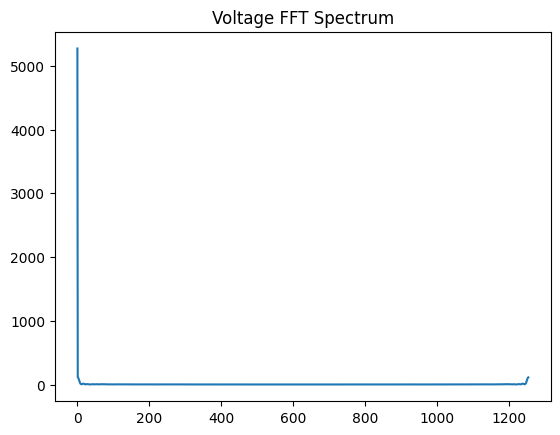

In [7]:
sample_cycle = df[(df["cell_id"]==df["cell_id"].iloc[0]) &
                  (df["cycle"]==df["cycle"].iloc[0])]

spectrum = np.abs(fft(sample_cycle["voltage"].values))

plt.figure()
plt.plot(spectrum)
plt.title("Voltage FFT Spectrum")
plt.show()

## Extract Wavelet-Based Voltage Features

This step extracts **multi-scale features from the voltage signal using Wavelet Transform**.

- The **Discrete Wavelet Transform (DWT)** with the `db4` wavelet is applied to the voltage signal.
- The signal is decomposed into **multiple levels (level = 3)** capturing both low-frequency and high-frequency patterns.
- For each wavelet coefficient level, the following statistics are computed:
  - **Mean of absolute coefficients**
  - **Standard deviation**

These features capture **localized signal patterns and transient behaviors** in the battery voltage data across different frequency scales.

In [8]:
def extract_wavelet(group):
    signal = group["voltage"].values
    coeffs = pywt.wavedec(signal, 'db4', level=3)
    
    features = {}
    for i, c in enumerate(coeffs):
        features[f"wavelet_level_{i}_mean"] = np.mean(np.abs(c))
        features[f"wavelet_level_{i}_std"] = np.std(c)
        
    return pd.Series(features)

wavelet_features = df.groupby(["cell_id","cycle"]).apply(extract_wavelet).reset_index()

wavelet_features.head()

,cell_id,cycle,wavelet_level_0_mean,wavelet_level_0_std,wavelet_level_1_mean,wavelet_level_1_std,wavelet_level_2_mean,wavelet_level_2_std,wavelet_level_3_mean,wavelet_level_3_std
0,B0005,0,11.709766,0.339635,0.001612,0.020367,0.000536,0.006946,0.000352,0.006315
1,B0006,0,11.731933,0.278342,0.001793,0.022140,0.000606,0.007615,0.000399,0.006962
2,B0007,0,11.699465,0.377884,0.001464,0.017614,0.000423,0.005212,0.000304,0.004661
3,B0018,0,11.674928,0.385538,0.001977,0.024551,0.000628,0.008110,0.000421,0.007313
4,B0025,0,11.708535,0.376701,0.002347,0.029398,0.001156,0.023237,0.000376,0.007432


## Current Change Features

This step computes features related to **changes in current during each battery cycle**.

- `dI`: Difference in current between consecutive measurements within each `cell_id` and `cycle`.
- `dI_dt`: Rate of current change calculated as `dI / dt`.

These values are then aggregated per **cell and cycle** to compute:
- Mean
- Standard deviation
- Maximum

These features help capture **current dynamics and fluctuations** that may influence battery behavior.

In [9]:
df["dI"] = df.groupby(["cell_id","cycle"])["current"].diff()
df["dI_dt"] = df["dI"] / df["dt"]

current_features = df.groupby(["cell_id","cycle"]).agg({
    "dI_dt":["mean","std","max"]
})

current_features.columns = ["_".join(col) for col in current_features.columns]
current_features = current_features.reset_index()

## Thermal Change Features

This step computes features related to **temperature changes during each battery cycle**.

- `dT`: Difference in temperature between consecutive measurements within each `cell_id` and `cycle`.

These values are aggregated per **cell and cycle** to calculate:
- Mean temperature change
- Maximum temperature change

These features capture **thermal dynamics of the battery**, which can be useful for modeling battery behavior.

In [10]:
df["dT"] = df.groupby(["cell_id","cycle"])["temperature"].diff()

thermal_features = df.groupby(["cell_id","cycle"]).agg({
    "dT":["mean","max"]
})

thermal_features.columns = ["_".join(col) for col in thermal_features.columns]
thermal_features = thermal_features.reset_index()

## Combine Advanced Features

This step merges all engineered feature sets into a single dataset.

The following feature groups are combined using `cell_id` and `cycle` as keys:
- Voltage rate features (`dV_dt`)
- Voltage drop event counts
- FFT-based frequency features
- Wavelet transform features
- Current change features
- Thermal change features

The resulting `advanced_features` dataset contains all advanced features for each battery cycle and is ready for further analysis or modeling.

In [ ]:
advanced_features = dvdt_features \
    .merge(motif_counts, on=["cell_id","cycle"]) \
    .merge(fft_features, on=["cell_id","cycle"]) \
    .merge(wavelet_features, on=["cell_id","cycle"]) \
    .merge(current_features, on=["cell_id","cycle"]) \
    .merge(thermal_features, on=["cell_id","cycle"])

advanced_features.head()

,cell_id,cycle,dV_dt_mean,dV_dt_std,dV_dt_min,dV_dt_max,voltage_drop_event,fft_mean,fft_std,fft_max,...,wavelet_level_1_std,wavelet_level_2_mean,wavelet_level_2_std,wavelet_level_3_mean,wavelet_level_3_std,dI_dt_mean,dI_dt_std,dI_dt_max,dT_mean,dT_max
0,B0005,0,0.000163,0.008913,-0.332256,0.445253,1,5.636299,258.909750,16167.340779,...,0.020367,0.000536,0.006946,0.000352,0.006315,-0.000049,0.007987,0.037681,5.779837e-07,5.181719
1,B0006,0,0.000135,0.009798,-0.364780,0.490291,1,5.449263,259.315125,16194.182084,...,0.022140,0.000606,0.007615,0.000399,0.006962,-0.000041,0.015539,0.079510,9.040938e-06,5.291898
2,B0007,0,0.000194,0.006491,-0.215973,0.340512,1,5.782742,258.748612,16156.327569,...,0.017614,0.000423,0.005212,0.000304,0.004661,-0.000049,0.007989,0.033782,6.433183e-07,3.746864
3,B0018,0,0.000224,0.010339,-0.374064,0.510940,1,5.985720,254.170557,15619.074680,...,0.024551,0.000628,0.008110,0.000421,0.007313,0.000046,0.006375,0.031905,-3.266842e-07,4.841888
4,B0025,0,0.000131,0.016115,-0.996064,0.569048,3,6.256574,362.076788,31619.174463,...,0.029398,0.001156,0.023237,0.000376,0.007432,-0.000062,0.007793,0.470833,4.338471e-06,4.549477


## Feature Grouping

This step organizes engineered features into **different feature groups** for easier experimentation and comparison.

- **Baseline Features** – basic statistical voltage features (`voltage_mean`, `voltage_std`)
- **Spectral Features** – features derived from FFT analysis of the voltage signal
- **Wavelet Features** – multi-scale features obtained from wavelet decomposition
- **Derivative Features** – features related to the rate of voltage change (`dV_dt`)

Grouping features this way helps evaluate **how different feature types impact model performance**.

In [12]:
baseline_features = ["voltage_mean","voltage_std"]
spectral_features = [col for col in advanced_features.columns if "fft" in col]
wavelet_cols = [col for col in advanced_features.columns if "wavelet" in col]
derivative_features = [col for col in advanced_features.columns if "dV_dt" in col]

In [13]:
advanced_features.to_csv(
    DATA_PROCESSED/"battery_advanced_features_week4.csv",
    index=False
)

print("Saved battery_advanced_features_week4.csv")

Saved battery_advanced_features_week4.csv
